In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import pickle

seed = 42
rng = np.random.default_rng(seed)

In [2]:
fname = Path("/src/project/data/experiment/samples_across_I_sigma.npy")

In [3]:
with open(fname, "rb") as f:
    samples = pickle.load(f)

In [4]:
len(samples)

10

In [5]:
I_sigmas = np.arange(start=1, stop=100, step=10)

In [6]:
x_samples = samples[0][0]["posterior"]["X"].data

In [7]:
x_samples.shape

(4, 1000, 27)

In [8]:
x_samples[:,:,14].shape

(4, 1000)

In [9]:
neuron_id = 14

In [10]:
mei_samples = samples[0][0]["posterior"]["X"].data[:, :, neuron_id]

In [11]:
mei_samples.shape

(4, 1000)

In [12]:
completing_perc_means = []
completing_perc_sdes = []
disrupting_perc_means = []
disrupting_perc_sdes = []
for sample_set in samples:
    mei_samples = sample_set[0]["posterior"]["X"].data[:, :, neuron_id]
    n_chains = mei_samples.shape[0]
    mei_means = np.mean(mei_samples, axis=-1)
    
    completing_samples = sample_set[1]["posterior"]["X"].data[:, :, neuron_id]
    completing_means = np.mean(completing_samples, axis=-1)
    
    disrupting_samples = sample_set[2]["posterior"]["X"].data[:, :, neuron_id]
    disrupting_means = np.mean(disrupting_samples, axis=-1)

    completing_perc_change = (completing_means - mei_means) / mei_means * 100
    completing_perc_change_mean = np.mean(completing_perc_change)
    completing_perc_means.append(completing_perc_change_mean)
    completing_perc_change_sde = np.std(completing_perc_change) / np.sqrt(n_chains)
    completing_perc_sdes.append(completing_perc_change_sde)

    disrupting_perc_change = (disrupting_means - mei_means) / mei_means * 100
    disrupting_perc_change_mean = np.mean(disrupting_perc_change)
    disrupting_perc_means.append(disrupting_perc_change_mean)
    disrupting_perc_change_sde = np.std(disrupting_perc_change) / np.sqrt(n_chains)
    disrupting_perc_sdes.append(disrupting_perc_change_sde)


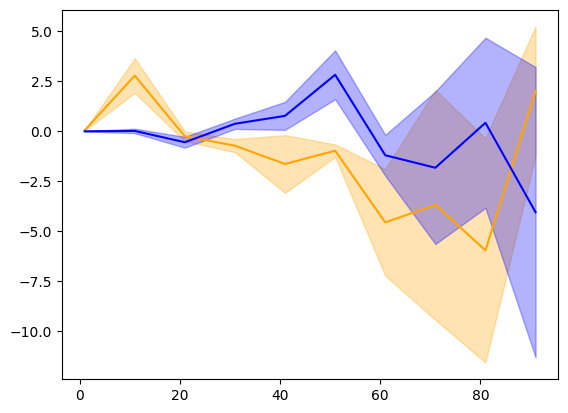

In [16]:
plt.plot(I_sigmas, completing_perc_means, label="Completing", color="orange")
plt.fill_between(I_sigmas, np.array(completing_perc_means) - np.array(completing_perc_sdes), np.array(completing_perc_means) + np.array(completing_perc_sdes), alpha=0.3, color="orange")
plt.plot(I_sigmas, disrupting_perc_means, label="Disrupting", color="blue")
plt.fill_between(I_sigmas, np.array(disrupting_perc_means) - np.array(disrupting_perc_sdes), np.array(disrupting_perc_means) + np.array(disrupting_perc_sdes), alpha=0.3, color="blue")